# 02 Changepoint Detection (CPD)

We compare four CPD methods on STOXX 600 stocks, using the processed dataset produced by `01_data_loading.ipynb`

| # | Method | Signal | Mode | Score |
|---|---|---|---|---|
| 1 | **Binary Segmentation** | Mean (L2 cost) | Offline | Binary |
| 2 | **CUSUM (combined μ + σ²)** | Mean & variance | Online, $O(1)$ | Binary + continuous (sigmoid) |
| 3 | **BOCPD** (Adams-MacKay 2007) | Mean & variance | Online, $O(t)$ | Continuous (posterior) |
| 4 | **GP Matérn 3/2 + CP kernel** | Mean, variance, correlation | Online (sliding window) | Continuous (ν, γ) |

### Some of the key points:

- **Jump process and rolling t-test** both overlap with CUSUM (all three detect shifts in the local mean via deviation from a reference) and neither offers anything CUSUM doesn't.
- **Added Binary Segmentation** as an **offline baseline method**. Offline methods see the full series and should dominate recall by design; if the online methods approach that ceiling, we know they're doing well.
- **Kept BOCPD and GP** because they're the two methods that produce genuinely continuous scores (the key property Wood, Roberts & Zohren (2022) argue matters for downstream use in the DMN).

This notebook has a toggle (`USE_DENOISED`) that runs the entire comparison on either raw or denoised (sector-relative) returns. Note that according to WRZ (2022) methodology we use arithmetic returns.

In [6]:
import warnings, time, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
from scipy.special import logsumexp
from sklearn.metrics import roc_auc_score, precision_score
import ruptures as rpt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

sys.path.insert(0, str(PROJECT_ROOT))
from src.cpd import binary_segmentation, cusum_combined, bocpd, cpd_scores

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (14, 4), "figure.dpi": 100,  "axes.grid": False})

## Load processed stock data

In [31]:
USE_DENOISED = False

df = pd.read_csv(
    PROJECT_ROOT / "data/processed/stoxx600/stoxx600_processed.csv",
    parse_dates=["date"], 
    usecols=["date", "ticker", "price", "sector", "1d_arith_ret", "1d_arith_ret_rel"],
)

print(f"Loaded {df['ticker'].nunique()} tickers, {len(df):,} rows")
print(f"Denoising mode: {'ON (sector-relative returns)' if USE_DENOISED else 'OFF (raw returns)'}")

Loaded 776 tickers, 2,391,730 rows
Denoising mode: OFF (raw returns)


In [32]:
CANDIDATE_STOCKS = ["TTE FP","BARC LN","SAP GY","NOVN SE","ENEL IM","NOVOB DC"]
STOCKS = [t for t in CANDIDATE_STOCKS if t in df["ticker"].unique()]
if not STOCKS:
    STOCKS = (df.groupby("ticker")["date"].count()
                .sort_values(ascending=False).head(8).index.tolist())
    print(f"(Fallback) using top-coverage tickers: {STOCKS}")
else:
    print(f"Using {len(STOCKS)} blue-chip stocks: {STOCKS}")

Using 5 blue-chip stocks: ['TTE FP', 'BARC LN', 'SAP GY', 'ENEL IM', 'NOVOB DC']


In [33]:
KNOWN_EVENTS = {
    # 2007-2009: Global Financial Crisis 
    "BNP Paribas freezes subprime funds":       pd.Timestamp("2007-08-09"), # The "start" of the European credit crunch
    "SocGen rogue trader / Black Monday":       pd.Timestamp("2008-01-21"), # Massive European selloff
    "Bear Stearns collapse":                    pd.Timestamp("2008-03-14"),
    "Lehman Brothers bankruptcy":               pd.Timestamp("2008-09-15"),
    "GFC market nadir / rally start":           pd.Timestamp("2009-03-09"),

    # 2010-2013: European Sovereign Debt Crisis
    "Greek debt downgrade (Fitch)":             pd.Timestamp("2009-12-08"), # Ignited the sovereign debt crisis
    "First Greek Bailout agreed":               pd.Timestamp("2010-05-02"),
    "Irish bailout agreed":                     pd.Timestamp("2010-11-28"),
    "US downgrade / EU contagion fear":         pd.Timestamp("2011-08-08"), # Massive global equity selloff
    "ECB massive LTRO injection":               pd.Timestamp("2011-12-21"), # Calmed European bank liquidity
    "Draghi 'Whatever it takes' speech":        pd.Timestamp("2012-07-26"), # The ultimate turning point for the Euro crisis
    "Cyprus banking crisis / bail-in":          pd.Timestamp("2013-03-16"), # Unprecedented depositor haircut

    # 2015 regime shift
    "SNB removes EUR/CHF floor":                pd.Timestamp("2015-01-15"),
    "ECB QE launch":                            pd.Timestamp("2015-01-22"),
    "Greek capital controls / bank holiday":    pd.Timestamp("2015-06-29"),
    "China Black Monday":                       pd.Timestamp("2015-08-24"),

    # 2016-2018 
    "Brexit vote":                              pd.Timestamp("2016-06-24"),
    "Trump election 2016":                      pd.Timestamp("2016-11-09"),
    "Volmageddon (XIV implosion)":              pd.Timestamp("2018-02-05"),
    "Italy BTP selloff / populist coalition":   pd.Timestamp("2018-05-29"),
    "Q4 2018 selloff":                          pd.Timestamp("2018-10-10"),

    # COVID
    "COVID crash":                              pd.Timestamp("2020-02-24"),
    "COVID recovery":                           pd.Timestamp("2020-03-23"),

    # Inflation / war regime (2022)
    "Rate-hike selloff":                        pd.Timestamp("2022-01-05"),
    "Russia-Ukraine war":                       pd.Timestamp("2022-02-24"),
    "UK mini-budget (Truss)":                   pd.Timestamp("2022-09-26"),

    # 2023
    "SVB collapse":                             pd.Timestamp("2023-03-10"),
    "Credit Suisse / UBS rescue":               pd.Timestamp("2023-03-15"),
    "Israel-Hamas war":                         pd.Timestamp("2023-10-09"),

    # 2024
    "French snap election (Macron dissolutio)": pd.Timestamp("2024-06-10"),
    "Yen carry trade unwind":                   pd.Timestamp("2024-08-05"),
    "Trump election 2024":                      pd.Timestamp("2024-11-06"),

    # 2025
    "DeepSeek AI shock":                        pd.Timestamp("2025-01-27"),
    "German debt brake / Zeitenwende":          pd.Timestamp("2025-03-05"),
    "Trump 'Liberation Day' tariffs":           pd.Timestamp("2025-04-03"),
    "Liberation Day selloff nadir":             pd.Timestamp("2025-04-07"),
    "Tariff 90-day pause rebound":              pd.Timestamp("2025-04-09"),

    # 2026
    "US/Iran war":                              pd.Timestamp("2026-02-28"),
}
print(f"Known events: {len(KNOWN_EVENTS)}")

Known events: 38


In [34]:
def load_stock(ticker, use_denoised=USE_DENOISED):
    """..."""
    s = (df.loc[df["ticker"] == ticker]
           .sort_values("date").reset_index(drop=True)
           .dropna(subset=["price", "1d_arith_ret"]))
    
    dates = s["date"]
    prices = s["price"].values
    return_dates = dates.reset_index(drop=True)
    
    returns = (s["1d_arith_ret_rel"].values if use_denoised 
               else s["1d_arith_ret"].values)
    
    # Skip event mapping in denoised mode (KNOWN_EVENTS are macro-level
    # and don't correspond to changepoints in sector-relative returns)
    if use_denoised:
        event_idxs = []
    else:
        event_idxs = []
        for ev_date in KNOWN_EVENTS.values():
            deltas = (return_dates - ev_date).abs()
            if deltas.min() <= pd.Timedelta(days=7):
                event_idxs.append(int(deltas.idxmin()))
    
    return dates, prices, returns, return_dates, sorted(set(event_idxs))

PRIMARY = "SAN SQ" if "SAN SQ" in STOCKS else STOCKS[0]
dates_p, prices_p, returns_p, return_dates_p, events_p = load_stock(PRIMARY)
print(f"{PRIMARY}: {len(returns_p):,} returns, {len(events_p)} events matched")
print(f"Return stats: mean={returns_p.mean():.5f}, std={returns_p.std():.4f}")

TTE FP: 5,108 returns, 38 events matched
Return stats: mean=0.00019, std=0.0169


### Visualise raw vs denoised returns

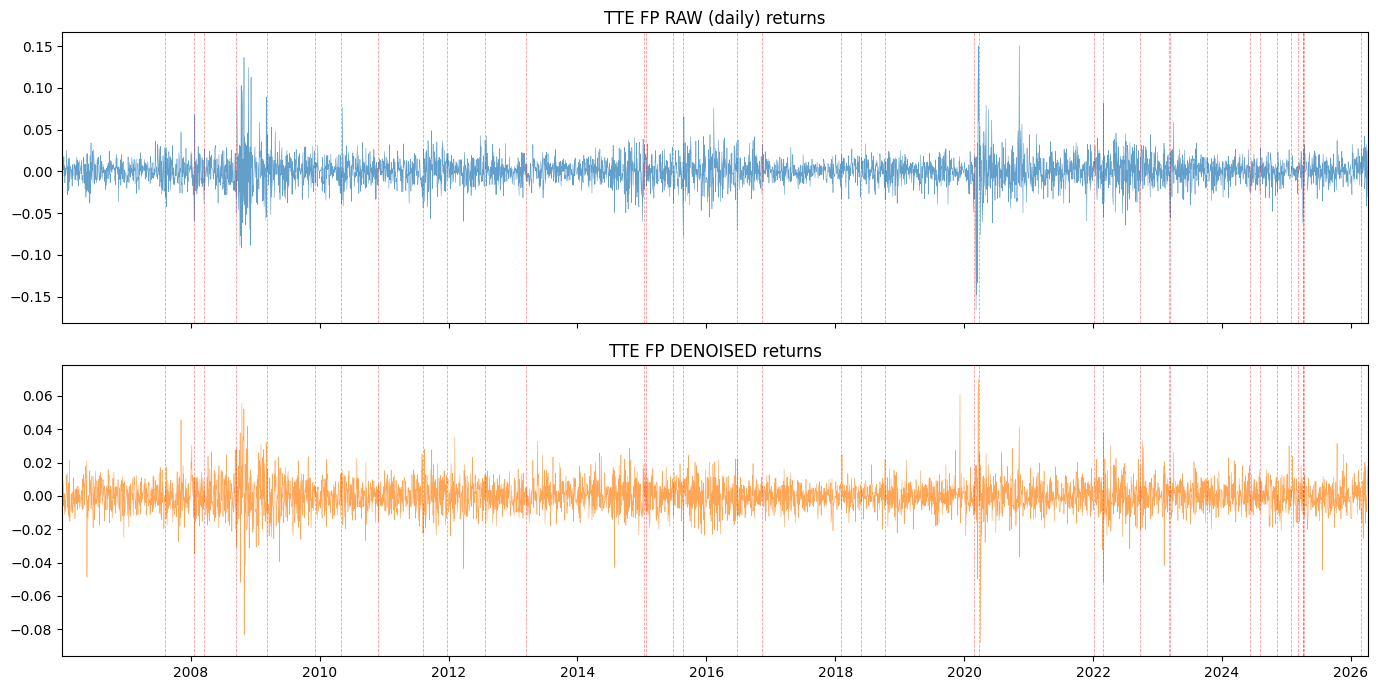

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

dates_raw, _, ret_raw, rdates_raw, _ = load_stock(PRIMARY, use_denoised=False)
dates_den, _, ret_den, rdates_den, _ = load_stock(PRIMARY, use_denoised=True)

axes[0].plot(rdates_raw, ret_raw, lw=0.4, alpha=0.7, color="C0")
axes[0].set_title(f"{PRIMARY} RAW (daily) returns")
axes[0].set_xlim(pd.to_datetime('2006-01-02'), pd.to_datetime('2026-04-10'))
for ev_date in KNOWN_EVENTS.values():
    axes[0].axvline(ev_date, color="red", ls="--", lw=0.6, alpha=0.4)

axes[1].plot(rdates_den, ret_den, lw=0.4, alpha=0.7, color="C1")
axes[1].set_title(f"{PRIMARY} DENOISED returns")
for ev_date in KNOWN_EVENTS.values():
    axes[1].axvline(ev_date, color="red", ls="--", lw=0.6, alpha=0.4)

plt.tight_layout(); plt.show()

## Evaluation framework

We score each detector against the known events with a tolerance of ±20 trading
days. The metrics are:

$$\mathrm{FPR} = \frac{|\text{detections that don't match any event}|}{|\text{all detections}|}$$

$$\mathrm{Recall} = \frac{|\text{events with at least one detection within tolerance}|}{|\text{events}|}$$

$$\text{Mean delay} = \text{avg}(t_{\text{detection}} - t_{\text{event}})$$

In [36]:
TOL_DAYS = 20

def evaluate_detections(detected, true_cps, tol=TOL_DAYS):
    detected = sorted(set(detected))
    true_cps = sorted(true_cps)
    if not detected:
        return dict(n_det=0, n_tp=0, n_fp=0, fpr=0.0, recall=0.0,
                    delays=[], mean_delay=np.nan)
    tp_set, matched = set(), {}
    for d in detected:
        for cp in true_cps:
            if abs(d - cp) <= tol:
                tp_set.add(d)
                if cp not in matched or abs(d - cp) < abs(matched[cp] - cp):
                    matched[cp] = d
                break
    n_tp = len(tp_set); n_fp = len(detected) - n_tp
    fpr = n_fp / len(detected)
    recall = len(matched) / len(true_cps) if true_cps else 1.0
    delays = [matched[cp] - cp for cp in true_cps if cp in matched]
    return dict(n_det=len(detected), n_tp=n_tp, n_fp=n_fp, fpr=fpr,
                recall=recall, delays=delays,
                mean_delay=float(np.mean(delays)) if delays else np.nan)

def evaluate_or_count(detected, true_cps, tol=TOL_DAYS, use_denoised=USE_DENOISED):
    """In raw mode, run full evaluation against KNOWN_EVENTS.
    In denoised mode, return only the detection count (no supervised metrics)."""
    if use_denoised:
        return dict(n_det=len(set(detected)), n_tp=np.nan, n_fp=np.nan,
                    fpr=np.nan, recall=np.nan, delays=[], mean_delay=np.nan)
    return evaluate_detections(detected, true_cps, tol)

def plot_detections(dates, prices, return_dates, detections, title, color="C0"):
    fig, ax = plt.subplots()
    ax.plot(dates, prices, lw=0.8, color="black", alpha=0.55)
    for ev_date in KNOWN_EVENTS.values():
        ax.axvline(ev_date, color="red", ls="--", lw=0.7, alpha=0.55)
    for d in detections:
        ax.axvline(return_dates.iloc[d], color=color, ls=":", lw=0.7, alpha=0.6)
    ax.plot([], [], color="red", ls="--", lw=1, label="known event")
    ax.plot([], [], color=color, ls=":", lw=1, label=f"detections ({len(detections)})")
    ax.set_title(title); ax.set_ylabel("price"); ax.legend(loc="upper left")
    ax.set_xlim(pd.to_datetime('2006-01-02'), pd.to_datetime('2026-04-10'))
    plt.tight_layout(); plt.show()

## Method 1: Binary Segmentation

Binary Segmentation is and **offline** CPD method: it sees the full return series at once so it has look-ahead bias by design. This gives it an informational advantage over online methods, so it acts as an upper-bound baseline, if the online methods come close, we know they're doing well.

**Algorithm**. Find the single best split point $t^*$ that minimises the total L2 cost:
$$t^* = \arg\min_{t} \left[\sum_{i=1}^{t} (r_i - \bar{r}_{1:t})^2 + \sum_{i=t+1}^{n} (r_i - \bar{r}_{t+1:n})^2\right]$$

Then recurse on each half. Stop when adding a split reduces cost by less than penalty $\beta$ (the BIC-like penalty controls the number of breaks). We use the `ruptures` library's implementation.

Binary Segmentation on TTE FP: {'n_det': 372, 'n_tp': 127, 'n_fp': 245, 'fpr': 0.6586021505376344, 'recall': 0.8157894736842105, 'delays': [1, 4, 0, -1, -1, 9, 2, 3, 1, -1, 1, -3, 0, -2, 4, 0, -4, 0, 5, 0, -1, 0, -1, -2, -1, 0, -7, 0, 3, 7, 6], 'mean_delay': 0.7096774193548387}


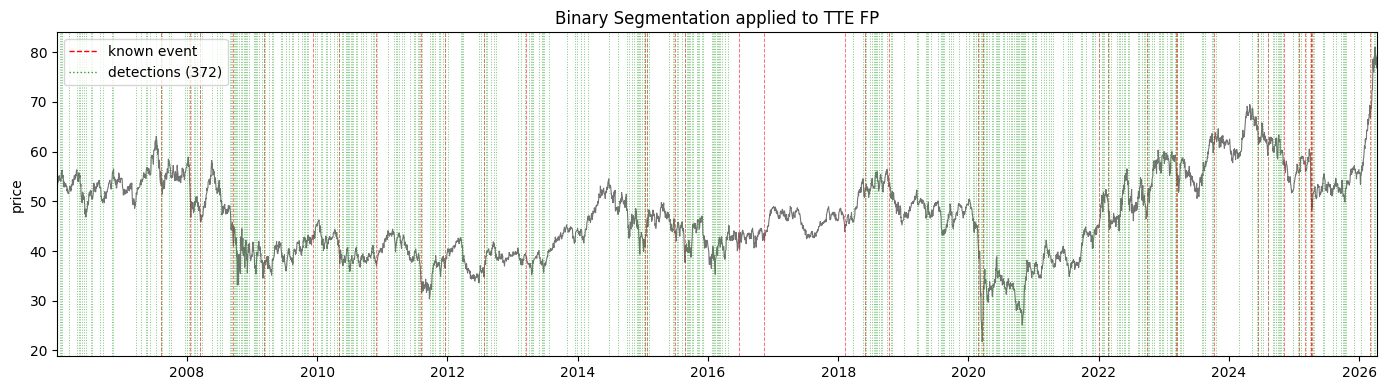

In [46]:
det_binseg = binary_segmentation(returns_p, penalty_mult=0.05, model="l2")
res_binseg = evaluate_or_count(det_binseg, events_p)
print(f"Binary Segmentation on {PRIMARY}: {res_binseg}")
plot_detections(dates_p, prices_p, return_dates_p, det_binseg,
                f"Binary Segmentation applied to {PRIMARY}", "C2")

In [44]:
# which model to use for binary segmentation? l2 or rbf (2nd seems too expensive computationally, and whats the difference)
t0 = time.time()
det = binary_segmentation(returns_p, penalty_mult=0.1, model="l2")
print(f"l2 model:  {time.time()-t0:.1f}s, {len(det)} detections")

t0 = time.time()
det = binary_segmentation(returns_p, penalty_mult=0.1, model="rbf")
print(f"rbf model: {time.time()-t0:.1f}s, {len(det)} detections")

l2 model:  0.8s, 70 detections
rbf model: 66.9s, 1021 detections


## Method 2: CUSUM (combined mean + variance)

Standard CUSUM tracks only the mean. We extend it to track **both moments
jointly** by maintaining two statistics:

**Mean component** (two-sided):
$$S_t^{+} = \max(0,\ S_{t-1}^{+} + z_t - k), \qquad
  S_t^{-} = \max(0,\ S_{t-1}^{-} - z_t - k)$$

**Variance component**: tracks deviations of $z_t^2$ from 1 (standardised
returns should have variance 1 under the null):
$$V_t = \max(0,\ V_{t-1} + (z_t^2 - 1) - k_v)$$

where $z_t = (r_t - \mu_{\text{ref}}) / \sigma_{\text{ref}}$ is the standardised
return against a rolling reference window. A changepoint is flagged when either
$\max(S_t^+, S_t^-) > h_\mu$ or $V_t > h_\sigma$.

**Continuous score**: $\nu_{\text{CUSUM}}(t) = \tanh\!\left(\max(S_t^+, S_t^-, V_t) / h\right) \in (0, 1)$,
which lets us compare against the GP's continuous output.

CUSUM on TTE FP: {'n_det': 126, 'n_tp': 41, 'n_fp': 85, 'fpr': 0.6746031746031746, 'recall': 0.7894736842105263, 'delays': [2, -3, 0, -3, 9, -1, -11, -2, 3, -8, -16, -5, 0, 0, -1, -4, 1, 1, 2, -12, 0, 1, 19, 19, -6, 2, -7, -1, 20, 10], 'mean_delay': 0.3}


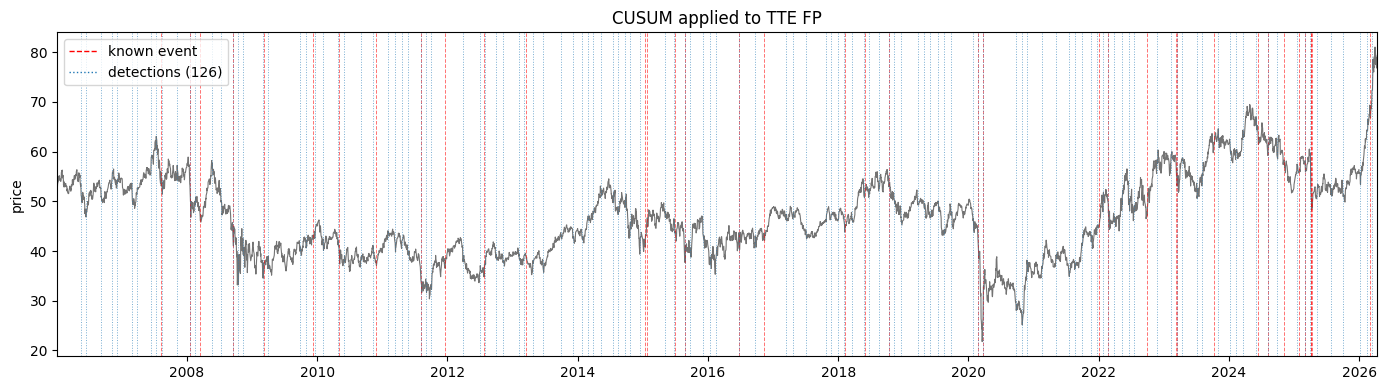

In [ ]:
det_cusum, score_cusum = cusum_combined(returns_p)
res_cusum = evaluate_or_count(det_cusum, events_p)
print(f"CUSUM on {PRIMARY}: {res_cusum}")
plot_detections(dates_p, prices_p, return_dates_p, det_cusum,
                f"CUSUM applied to {PRIMARY}", "C0")

## Method 3: Bayesian Online Changepoint Detection (BOCPD)

Bayesian Online Changepoint Detection maintains a posterior over the
**run length** $r_t$ (days since the last changepoint) using a Normal-Gamma
conjugate prior on $(\mu, \sigma^2)$.

**Recursive update**. At each step, run length either grows ($r_t = r_{t-1} + 1$)
with probability $1 - H$ or resets ($r_t = 0$) with probability $H$ (the hazard
rate):

$$P(r_{t+1} \mid r_{1:t+1})\ \propto\ \sum_{r_t} P(r_{t+1} \mid r_t)\ p(r_{t+1} \mid r_t)\ P(r_t \mid r_{1:t})$$

**Continuous score**: rather than just flagging
CPs via MAP-run-length drops, we extract the **posterior probability that the
current regime is very fresh**:

$$\nu_{\text{BOCPD}}(t) = P(r_t \leq r_{\text{fresh}}\ \mid\ r_{1:t})$$

with $r_{\text{fresh}} = 5$ by default. This score is well-calibrated (it's a
proper probability) and can be fed directly to a downstream LSTM.

BOCPD on TTE FP: {'n_det': 63, 'n_tp': 20, 'n_fp': 43, 'fpr': 0.6825396825396826, 'recall': 0.5, 'delays': [-3, 2, 4, 18, 5, 8, -3, 17, 19, 16, 0, 1, -20, 4, -7, 3, -7, 10, 11], 'mean_delay': 4.105263157894737}


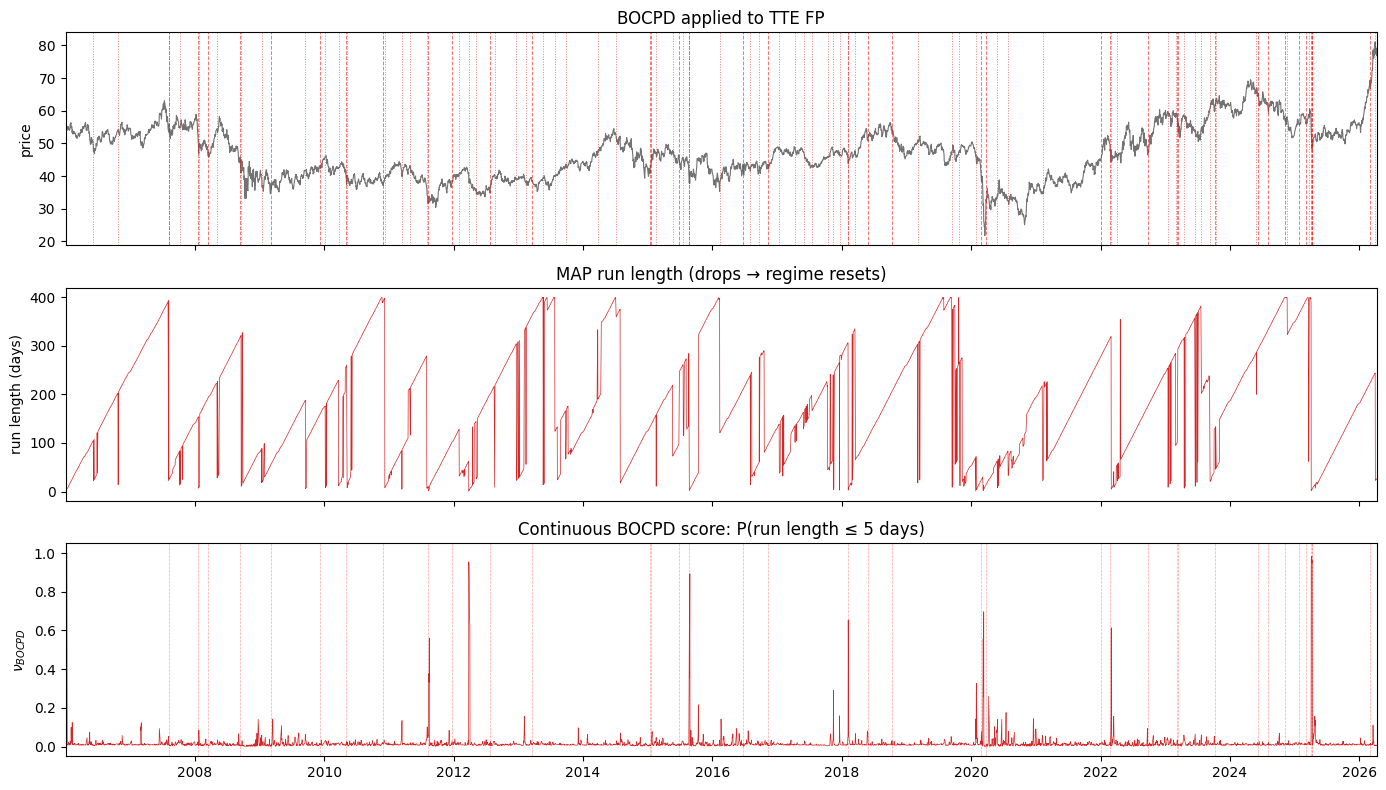

In [48]:
det_bocpd, map_rl, score_bocpd = bocpd(returns_p)
res_bocpd = evaluate_or_count(det_bocpd, events_p)
print(f"BOCPD on {PRIMARY}: {res_bocpd}")

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
axes[0].plot(dates_p, prices_p, lw=0.8, color="black", alpha=0.55)
for ev_date in KNOWN_EVENTS.values():
    axes[0].axvline(ev_date, color="red", ls="--", lw=0.7, alpha=0.55)
for d in det_bocpd:
    axes[0].axvline(return_dates_p.iloc[d], color="C3", ls=":", lw=0.7, alpha=0.6)
axes[0].set_title(f"BOCPD applied to {PRIMARY}")
axes[0].set_ylabel("price")
axes[0].set_xlim(pd.to_datetime('2006-01-02'), pd.to_datetime('2026-04-10'))

axes[1].plot(return_dates_p, map_rl, lw=0.5, color="C3")
axes[1].set_title("MAP run length (drops → regime resets)")
axes[1].set_ylabel("run length (days)")

axes[2].plot(return_dates_p, score_bocpd, lw=0.5, color="C3")
axes[2].set_title("Continuous BOCPD score: P(run length ≤ 5 days)")
axes[2].set_ylabel(r"$\nu_{BOCPD}$"); axes[2].set_ylim(-0.05, 1.05)
for ev_date in KNOWN_EVENTS.values():
    axes[2].axvline(ev_date, color="red", ls="--", lw=0.5, alpha=0.35)

plt.tight_layout(); plt.show()

## Method 4: GP Matérn 3/2 + Changepoint Kernel

Wood, Roberts & Zohren (2022) Section II. For each rolling window of length
`lbw`:

1. **Standardise** returns inside the window (paper eq. 2): zero-mean, unit-variance.
2. **Fit base GP** with Matérn 3/2 kernel $k_M$ → NLML $\mathcal{L}_M$.
3. **Fit changepoint GP** (sigmoid blend of two Matérn 3/2) → NLML $\mathcal{L}_{CP}$.
4. Compute severity and location (according to paper's eq. 10):
   $$\nu_t^{(i)} = 1-\frac{1}{1 + \exp(-(\mathcal{L}_M - \mathcal{L}_{CP}))} \in (0, 1),
     \qquad \gamma_t^{(i)} = \frac{c - (t - l)}{l} \in (0, 1)$$

The Matérn 3/2 kernel captures three types of breaks simultaneously:
- change in **input scale** $\lambda$ → shift in correlation length
- change in **output scale** $\sigma_h$ → shift in volatility
- change in noise $\sigma_n$ → shift in signal-to-noise ratio

Flag a CP when $\nu >$ threshold and $\gamma > 0.5$.

In [50]:
def detect_gp_cpd(
    returns: np.ndarray,
    lbw: int = 21, # NOTE that 21 is used as default lbw here, although the paper's optimum is 63. The full lbw's list is in the .yaml (actually commented bc we dont really need it)
    nu_threshold: float = 0.85,
    gamma_min: float = 0.5,
    cooldown: int = 20,
    stride: int = 1,
) -> tuple[list[int], np.ndarray, np.ndarray]:
    """GP-based CPD using the paper's Matérn 3/2 changepoint kernel."""
    n = len(returns)
    nu_arr = np.full(n, np.nan)
    gamma_arr = np.full(n, np.nan)
    detections = []
    last_det = -cooldown - 1

    for t in range(lbw, n, stride):
        window = returns[t - lbw : t]
        nu, gamma = cpd_scores(window, lbw)
        nu_arr[t] = nu
        gamma_arr[t] = gamma
        if nu > nu_threshold and gamma > gamma_min and (t - last_det) > cooldown:
            detections.append(t)
            last_det = t

    return detections, nu_arr, gamma_arr

det_gp, nu_arr, gamma_arr = detect_gp_cpd(
    returns_p, lbw=21, nu_threshold=0.85, gamma_min=0.5, cooldown=30, stride=10
)
res_gp = evaluate_or_count(det_gp, events_p, tol=20)
print(f"GP CPD on {PRIMARY}: {res_gp['n_det']} det, "
      f"FPR={res_gp['fpr']:.0%}, Recall={res_gp['recall']:.0%}, "
      f"Delay={res_gp['mean_delay']:.1f}d")

GP CPD on TTE FP: 62 det, FPR=74%, Recall=42%, Delay=0.9d


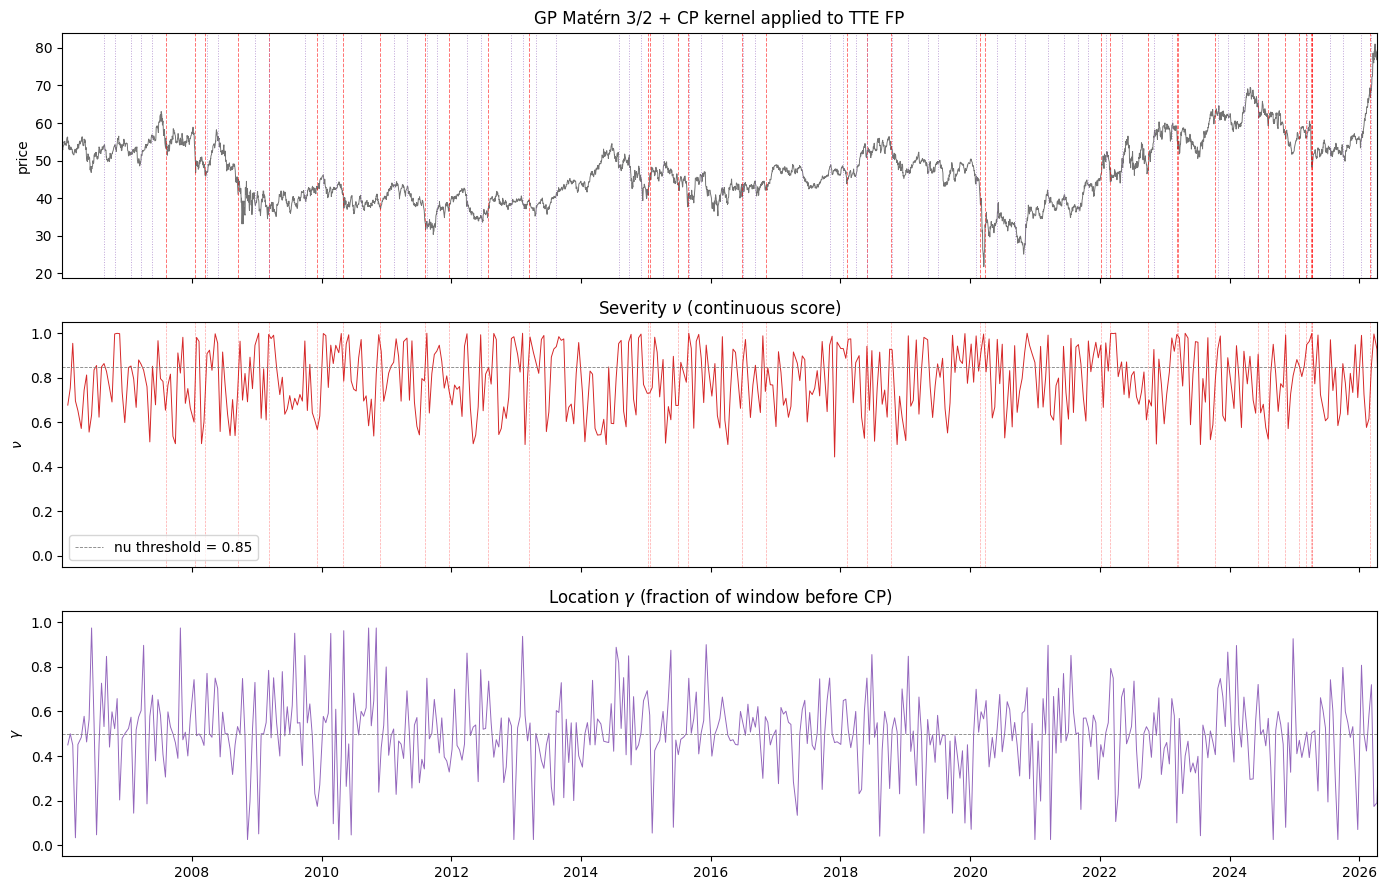

In [51]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(dates_p, prices_p, lw=0.7, color="black", alpha=0.55)
for ev_date in KNOWN_EVENTS.values():
    axes[0].axvline(ev_date, color="red", ls="--", lw=0.7, alpha=0.55)
for d in det_gp:
    axes[0].axvline(return_dates_p.iloc[d], color="C4", ls=":", lw=0.7, alpha=0.6)
axes[0].set_title(f"GP Matérn 3/2 + CP kernel applied to {PRIMARY}")
axes[0].set_ylabel("price")
axes[0].set_xlim(pd.to_datetime('2006-01-02'), pd.to_datetime('2026-04-10'))

idx = np.where(~np.isnan(nu_arr))[0]
axes[1].plot(return_dates_p.iloc[idx].values, nu_arr[idx], lw=0.7, color="C3")
axes[1].axhline(0.85, color="gray", ls="--", lw=0.6, label="nu threshold = 0.85")
for ev_date in KNOWN_EVENTS.values():
    axes[1].axvline(ev_date, color="red", ls="--", lw=0.5, alpha=0.35)
axes[1].set_title(r"Severity $\nu$ (continuous score)"); axes[1].legend(loc="lower left")
axes[1].set_ylabel(r"$\nu$"); axes[1].set_ylim(-0.05, 1.05)

axes[2].plot(return_dates_p.iloc[idx].values, gamma_arr[idx], lw=0.7, color="C4")
axes[2].axhline(0.5, color="gray", ls="--", lw=0.6)
axes[2].set_title(r"Location $\gamma$ (fraction of window before CP)")
axes[2].set_ylabel(r"$\gamma$"); axes[2].set_ylim(-0.05, 1.05)

plt.tight_layout(); plt.show()

### GP threshold calibration

If ν never exceeds 0.85 on your data, the default threshold is too strict.
Inspect the empirical distribution below to pick a better value.

In [52]:
nu_valid = nu_arr[~np.isnan(nu_arr)]
print(f"nu distribution on {PRIMARY} ({len(nu_valid)} windows):")
for q in [0.50, 0.75, 0.90, 0.95, 0.99, 1.00]:
    print(f"  q={q:.2f}: {np.quantile(nu_valid, q):.4f}")
for thr in [0.50, 0.70, 0.85, 0.95]:
    n_above = (nu_valid > thr).sum()
    print(f"  nu > {thr:.2f}: {n_above:4d} ({100*n_above/len(nu_valid):.1f}%)")

nu distribution on TTE FP (509 windows):
  q=0.50: 0.7964
  q=0.75: 0.9255
  q=0.90: 0.9793
  q=0.95: 0.9939
  q=0.99: 0.9996
  q=1.00: 1.0000
  nu > 0.50:  504 (99.0%)
  nu > 0.70:  347 (68.2%)
  nu > 0.85:  197 (38.7%)
  nu > 0.95:   98 (19.3%)


## Continuous-score comparison: CUSUM vs BOCPD vs GP

All three methods now emit scores in [0, 1]. This is the comparison that
matters for the DMN: downstream gradient-based models consume continuous
signals, not binary flags. Do the cheap methods produce signals that are
as informative as the GP's?

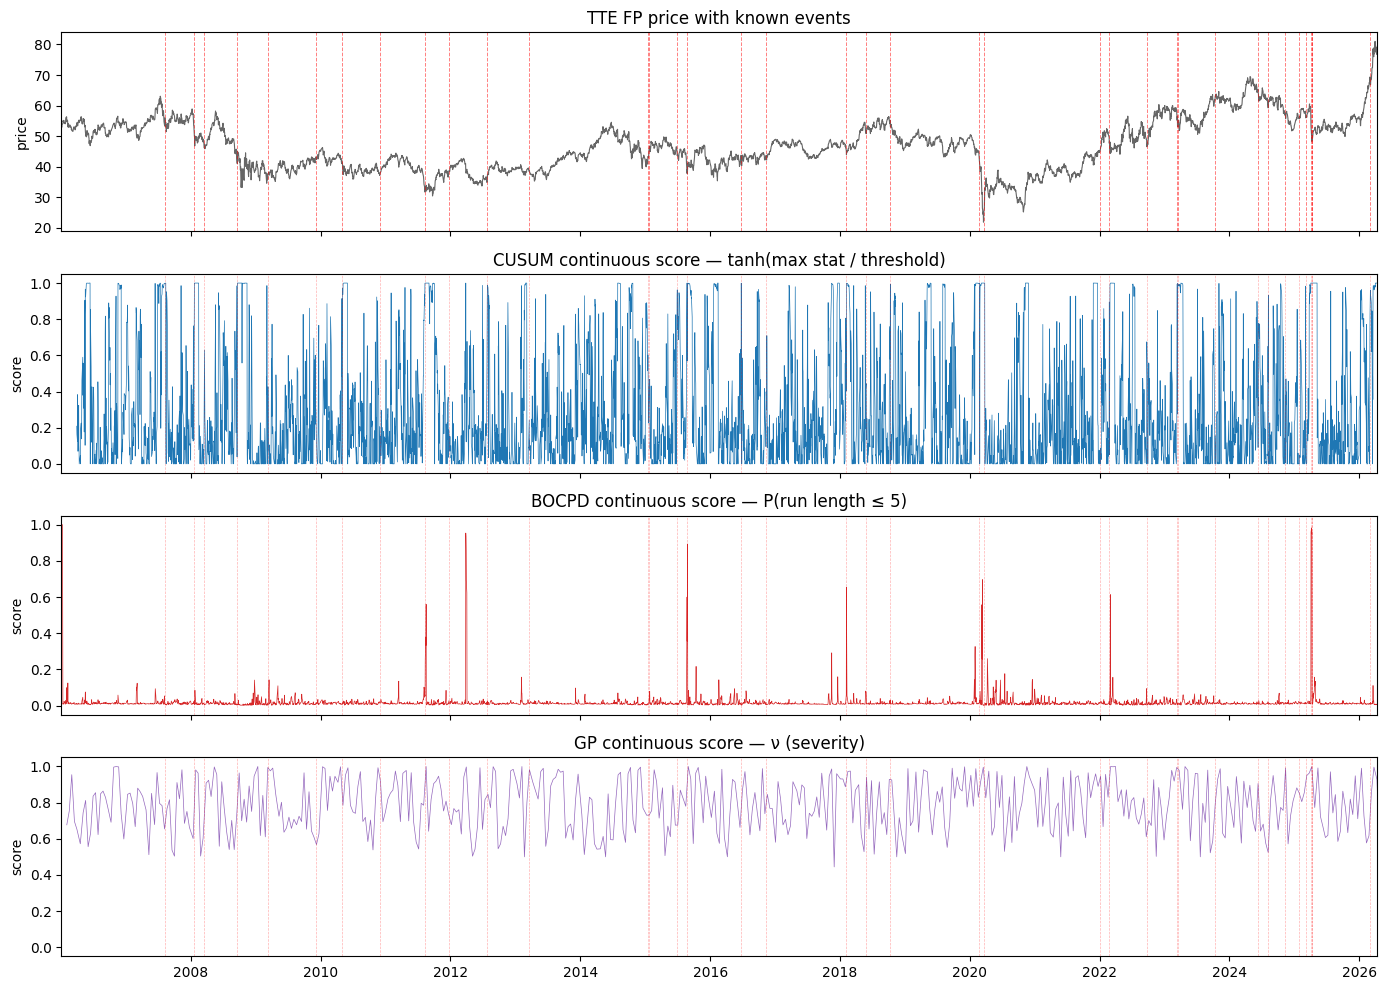

In [53]:
# Align all three scores on the same dates (GP has NaN on non-stride dates)
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

# Row 0: price + events
axes[0].plot(dates_p, prices_p, lw=0.8, color="black", alpha=0.6)
for ev_date in KNOWN_EVENTS.values():
    axes[0].axvline(ev_date, color="red", ls="--", lw=0.7, alpha=0.5)
axes[0].set_title(f"{PRIMARY} price with known events")
axes[0].set_ylabel("price")
axes[0].set_xlim(pd.to_datetime('2006-01-02'), pd.to_datetime('2026-04-10'))

# Row 1: CUSUM continuous
axes[1].plot(return_dates_p, score_cusum, lw=0.5, color="C0")
axes[1].set_title("CUSUM continuous score — tanh(max stat / threshold)")
axes[1].set_ylabel("score"); axes[1].set_ylim(-0.05, 1.05)
for ev_date in KNOWN_EVENTS.values():
    axes[1].axvline(ev_date, color="red", ls="--", lw=0.5, alpha=0.3)

# Row 2: BOCPD continuous
axes[2].plot(return_dates_p, score_bocpd, lw=0.5, color="C3")
axes[2].set_title("BOCPD continuous score — P(run length ≤ 5)")
axes[2].set_ylabel("score"); axes[2].set_ylim(-0.05, 1.05)
for ev_date in KNOWN_EVENTS.values():
    axes[2].axvline(ev_date, color="red", ls="--", lw=0.5, alpha=0.3)

# Row 3: GP continuous
idx = np.where(~np.isnan(nu_arr))[0]
axes[3].plot(return_dates_p.iloc[idx].values, nu_arr[idx], lw=0.5, color="C4")
axes[3].set_title("GP continuous score — ν (severity)")
axes[3].set_ylabel("score"); axes[3].set_ylim(-0.05, 1.05)
axes[3].set_xlabel("")
for ev_date in KNOWN_EVENTS.values():
    axes[3].axvline(ev_date, color="red", ls="--", lw=0.5, alpha=0.3)

plt.tight_layout(); plt.show()

## Single-stock results: all four methods

Binary detection metrics on `PRIMARY`. Binary Segmentation should show the
highest recall (offline advantage); the online methods should show lower but
comparable numbers.

In [54]:
single_results = {
    "CUSUM":                 res_cusum,
    "BOCPD":                 res_bocpd,
    "Binary Segmentation":   res_binseg,
    "GP Matérn 3/2":         res_gp,
}

summary = pd.DataFrame({
    name: {
        "Detections": r["n_det"], "TP": r["n_tp"], "FP": r["n_fp"],
        "FPR":        f"{r['fpr']:.1%}",
        "Recall":     f"{r['recall']:.1%}",
        "Mean delay": f"{r['mean_delay']:+.1f}d" if not np.isnan(r['mean_delay']) else "—",
    }
    for name, r in single_results.items()
}).T
denoising_label = "DENOISED" if USE_DENOISED else "RAW"
print(f"Results on {PRIMARY} | {denoising_label} returns | {len(events_p)} events, tol=±{TOL_DAYS}d:")
print(summary.to_string())

Results on TTE FP | RAW returns | 38 events, tol=±20d:
                    Detections   TP   FP    FPR Recall Mean delay
CUSUM                      126   41   85  67.5%  78.9%      +0.3d
BOCPD                       63   20   43  68.3%  50.0%      +4.1d
Binary Segmentation        372  127  245  65.9%  81.6%      +0.7d
GP Matérn 3/2               62   16   46  74.2%  42.1%      +0.9d


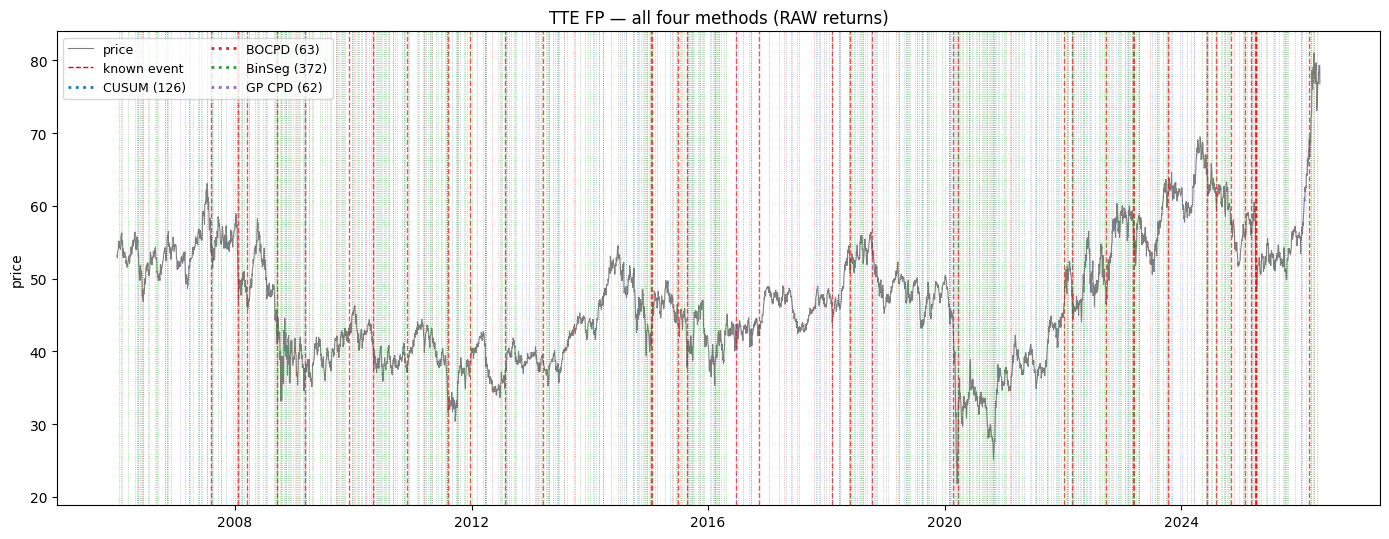

In [55]:
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(dates_p, prices_p, lw=0.8, color="black", alpha=0.5, label="price")
for ev_date in KNOWN_EVENTS.values():
    ax.axvline(ev_date, color="red", ls="--", lw=1, alpha=0.7)
ax.plot([], [], color="red", ls="--", lw=1, label="known event")

configs = [
    (det_cusum,   "CUSUM",    "C0"),
    (det_bocpd,   "BOCPD",    "C3"),
    (det_binseg,  "BinSeg",   "C2"),
    (det_gp,      "GP CPD",   "C4"),
]
for dets, name, color in configs:
    for d in dets:
        ax.axvline(return_dates_p.iloc[d], color=color, ls=":", lw=0.6, alpha=0.5)
    if dets:
        ax.plot([], [], color=color, ls=":", lw=2, label=f"{name} ({len(dets)})")

ax.set_title(f"{PRIMARY} — all four methods ({denoising_label} returns)")
ax.set_ylabel("price"); ax.legend(loc="upper left", ncol=2, fontsize=9)
plt.tight_layout(); plt.show()

## Multi-stock evaluation (run for approx 8 min)

In [56]:
METHOD_NAMES = list(single_results.keys())
# Initialize all keys upfront to avoid KeyErrors and ensure consistency
multi = {m: {"fpr": [], "recall": [], "delay": [], "n_det": []} for m in METHOD_NAMES}

denoising_label = "DENOISED" if USE_DENOISED else "RAW"
print(f"Running 4 methods on {len(STOCKS)} stocks ({denoising_label} returns)...")

for ticker in STOCKS:
    _, _, ret, _, ev_idx = load_stock(ticker)
    
    # In RAW mode, we need events to calculate metrics. 
    # In DENOISED mode, we process even if ev_idx is empty to get detection counts.
    if not USE_DENOISED and not ev_idx:
        continue

    # Run all four detection methods
    results = {
        "CUSUM":                 cusum_combined(ret)[0],
        "BOCPD":                 bocpd(ret)[0],
        "Binary Segmentation":   binary_segmentation(ret, penalty_mult=0.25),
        "GP Matérn 3/2":         detect_gp_cpd(ret, lbw=21, cooldown=30, stride=20)[0],
    }
    
    for name, dets in results.items():
        ev = evaluate_or_count(dets, ev_idx)
        # Populate metrics lists
        multi[name]["fpr"].append(ev["fpr"])
        multi[name]["recall"].append(ev["recall"])
        multi[name]["delay"].append(ev["mean_delay"])
        multi[name]["n_det"].append(ev["n_det"])
    
    print(f"  {ticker}: done")

# Check if we actually collected data to avoid "zero-size array" errors in summary
if not multi[METHOD_NAMES[0]]["n_det"]:
    print("WARNING: No data collected. Check STOCKS list or load_stock function.")
else:
    if USE_DENOISED:
        # Summary for Denoised mode (Focus on detection counts)
        multi_summary = pd.DataFrame({
            name: {
                "Mean detections": f"{np.mean(v['n_det']):.1f}",
                "Std detections":  f"{np.std(v['n_det']):.1f}",
                "Min detections":  f"{int(np.min(v['n_det']))}",
                "Max detections":  f"{int(np.max(v['n_det']))}",
            }
            for name, v in multi.items()
        }).T
    else:
        # Summary for Raw mode (Focus on supervised metrics against KNOWN_EVENTS)
        multi_summary = pd.DataFrame({
            name: {
                "Mean FPR":    f"{np.mean(v['fpr']):.1%}",
                "Std FPR":     f"{np.std(v['fpr']):.1%}",
                "Mean Recall": f"{np.mean(v['recall']):.1%}",
                "Std Recall":  f"{np.std(v['recall']):.1%}",
                "Mean delay":  f"{np.nanmean(v['delay']):+.1f}d",
            }
            for name, v in multi.items()
        }).T

    print(f"\nAggregated across {len(STOCKS)} stocks ({denoising_label}):")
    print(multi_summary.to_string())

Running 4 methods on 5 stocks (RAW returns)...
  TTE FP: done
  BARC LN: done
  SAP GY: done
  ENEL IM: done
  NOVOB DC: done

Aggregated across 5 stocks (RAW):
                    Mean FPR Std FPR Mean Recall Std Recall Mean delay
CUSUM                  67.3%    4.0%       78.4%       9.5%      -0.9d
BOCPD                  67.3%    0.7%       51.1%       2.7%      +2.4d
Binary Segmentation    73.3%    0.5%       95.8%       1.3%      +1.2d
GP Matérn 3/2          69.2%    4.6%       35.3%       6.4%      -0.5d


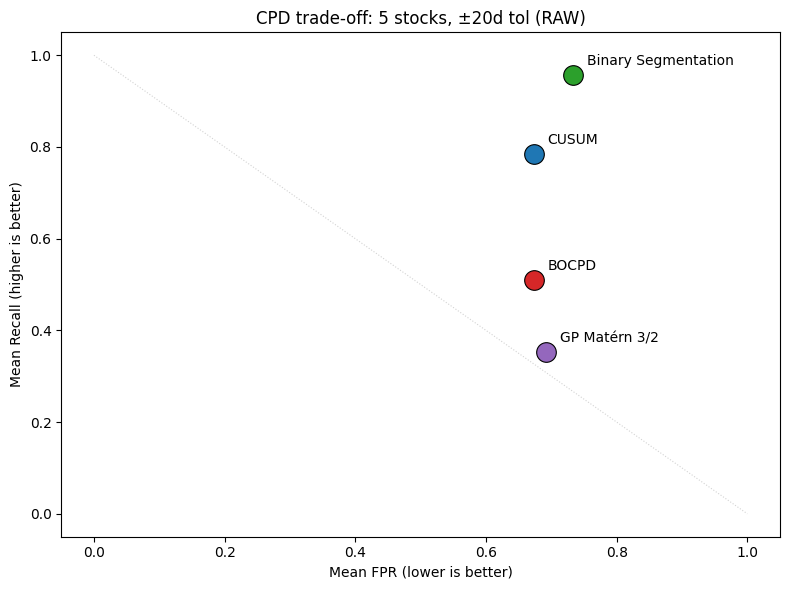

In [57]:
if not USE_DENOISED:
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = {"CUSUM": "C0", "BOCPD": "C3",
              "Binary Segmentation": "C2", "GP Matérn 3/2": "C4"}
    for name, v in multi.items():
        mean_fpr, mean_rec = np.mean(v["fpr"]), np.mean(v["recall"])
        ax.scatter(mean_fpr, mean_rec, s=200, color=colors[name], zorder=5,
                   edgecolors="black", linewidth=0.8)
        ax.annotate(name, (mean_fpr, mean_rec),
                    textcoords="offset points", xytext=(10, 7), fontsize=10)
    ax.set_xlabel("Mean FPR (lower is better)")
    ax.set_ylabel("Mean Recall (higher is better)")
    ax.set_title(f"CPD trade-off: {len(STOCKS)} stocks, ±{TOL_DAYS}d tol ({denoising_label})")
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    ax.plot([0, 1], [1, 0], color="lightgray", ls=":", lw=0.8)
    plt.tight_layout(); plt.show()
else:
    # In denoised mode, show detection counts per method instead
    fig, ax = plt.subplots(figsize=(9, 5))
    colors_list = ["C0", "C3", "C2", "C4"]
    means = [np.mean(multi[m]["n_det"]) for m in METHOD_NAMES]
    stds  = [np.std(multi[m]["n_det"])  for m in METHOD_NAMES]
    ax.bar(METHOD_NAMES, means, yerr=stds, color=colors_list,
           edgecolor="black", linewidth=0.8, capsize=5)
    ax.set_ylabel("Mean detections per stock")
    ax.set_title(f"Detection count per method ({denoising_label} returns, "
                 f"{len(STOCKS)} stocks)")
    plt.xticks(rotation=15)
    plt.tight_layout(); plt.show()

In [58]:
def score_auc(score, event_idxs, tol=20):
    """AUC of continuous score against 'is within tol of any event' indicator."""
    n = len(score)
    label = np.zeros(n)
    for ev in event_idxs:
        lo, hi = max(0, ev - tol), min(n, ev + tol + 1)
        label[lo:hi] = 1
    valid = ~np.isnan(score)
    return roc_auc_score(label[valid], score[valid])

if USE_DENOISED:
    print("AUC scoring skipped (denoised mode has no labels).")
else:
    print(f"CUSUM AUC:  {score_auc(score_cusum, events_p):.3f}")
    print(f"BOCPD AUC:  {score_auc(score_bocpd, events_p):.3f}")
    print(f"GP AUC:     {score_auc(nu_arr, events_p):.3f}")

CUSUM AUC:  0.605
BOCPD AUC:  0.531
GP AUC:     0.551


**Final comments/open problems-questions**:

- The only true way to evaluate if GP > BOCPD > CUSUM on denoised returns is to pass their continuous scores into the LSTM and see which one yields the highest out-of-sample Sharpe ratio.
- The `cooldown=20` for CUSUM/BOCPD/GP means the methods can't flag two events within 20 days, but we have several event clusters that are within days of each other.
- The `KNOWN_EVENTS` are global market events but we evaluate stock-by-stock and we are penalising methods for not detecting events that aren't actually changepoints in that stock's return series. The Recall metric is therefore biased downward in a way that depends on which stocks we pick.

## Additional diagnostics


### Cross-method score correlation

Are the three continuous scores (CUSUM, BOCPD, GP) measuring the same thing, or do they capture complementary aspects of regime change? High correlation means the cheap methods are sufficient; low correlation means the GP adds information the simpler methods miss.

In [59]:
score_df = pd.DataFrame({
    "CUSUM": score_cusum,
    "BOCPD": score_bocpd,
    "GP":    nu_arr,
}, index=return_dates_p).dropna()

print(f"Cross-method score correlation on {PRIMARY} ({len(score_df)} aligned obs):")
print(score_df.corr().round(3).to_string())

Cross-method score correlation on TTE FP (505 aligned obs):
       CUSUM  BOCPD     GP
CUSUM  1.000  0.119  0.135
BOCPD  0.119  1.000  0.126
GP     0.135  0.126  1.000


### Detection rate over time

How many detections per year does each method emit, on the primary stock? Should roughly track macro-event density (more detections during 2008-2009, 2020, 2022, fewer during quiet periods like 2017).

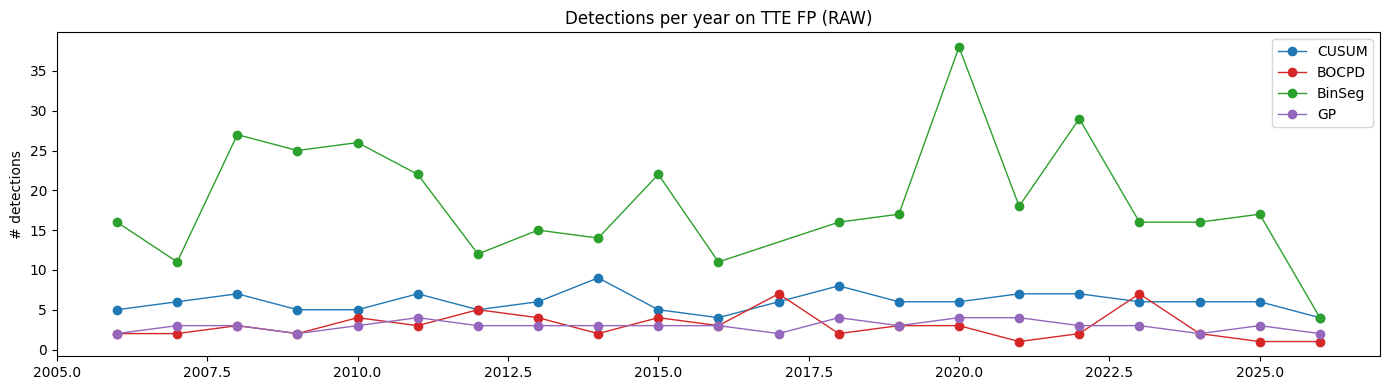

In [60]:
fig, ax = plt.subplots(figsize=(14, 4))
configs = [
    (det_cusum,  "CUSUM",   "C0"),
    (det_bocpd,  "BOCPD",   "C3"),
    (det_binseg, "BinSeg",  "C2"),
    (det_gp,     "GP",      "C4"),
]
for dets, name, color in configs:
    if not dets:
        continue
    years = pd.Series([return_dates_p.iloc[d].year for d in dets])
    counts = years.value_counts().sort_index()
    ax.plot(counts.index, counts.values, marker="o", lw=1, label=name, color=color)
ax.set_title(f"Detections per year on {PRIMARY} ({denoising_label})")
ax.set_ylabel("# detections"); ax.legend()
plt.tight_layout(); plt.show()